In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
from ipywidgets import interact

In [ ]:

# Data Preprocessing
df = pd.read_csv("unsupervised_modelling_validation_v2.csv")

# ID columns
id_cols = ["Booking ID", "Customer ID"]
df_features = df.drop(columns=[c for c in id_cols if c in df.columns])

# Create a stratification key
df_features["strata"] = df_features["Vehicle Type"].astype(str)

# One-hot encode categorical variables
df_ohe = pd.get_dummies(df_features.drop(columns=["strata"]), drop_first=True)

# Scale
scaler = RobustScaler()
X = scaler.fit_transform(df_ohe)


# Stratified Sampling (30%)
_, df_sample_idx = train_test_split(
    df_features,
    test_size=0.3,
    random_state=42,
    stratify=df_features["strata"]
)

# Align with one-hot encoded features
X_sample = df_ohe.loc[df_sample_idx.index].values

# Save sampled data as CSV
# Convert the NumPy array back to a DataFrame with the original encoded column names
X_sample_df = pd.DataFrame(X_sample, columns=df_ohe.columns)

# Optionally add the original strata or Vehicle Type back for reference
X_sample_df["Vehicle Type"] = df_features.loc[df_sample_idx.index, "Vehicle Type"].values

# Save to CSV
X_sample_df.to_csv("unsupervised_sampled_data.csv", index=False)

print(f"{X_sample_df.shape}")

(43795, 22)


Clustering Fit 

    k  Silhouette  Davies-Bouldin  Calinski-Harabasz          WCSS
0   2    0.671636        0.626934       51200.984146  2.183124e+09
1   3    0.558697        0.577276       57587.206940  1.304546e+09
2   4    0.613543        0.496985       83368.151465  7.056054e+08
3   5    0.630561        0.490349      107866.394439  4.363326e+08
4   7    0.563313        0.539725      122984.604163  2.652695e+08
5   8    0.564832        0.553105      139830.938777  2.027729e+08
6  10    0.514729        0.614010      153247.253345  1.457093e+08
7  12    0.510656        0.631321      157700.476045  1.165801e+08


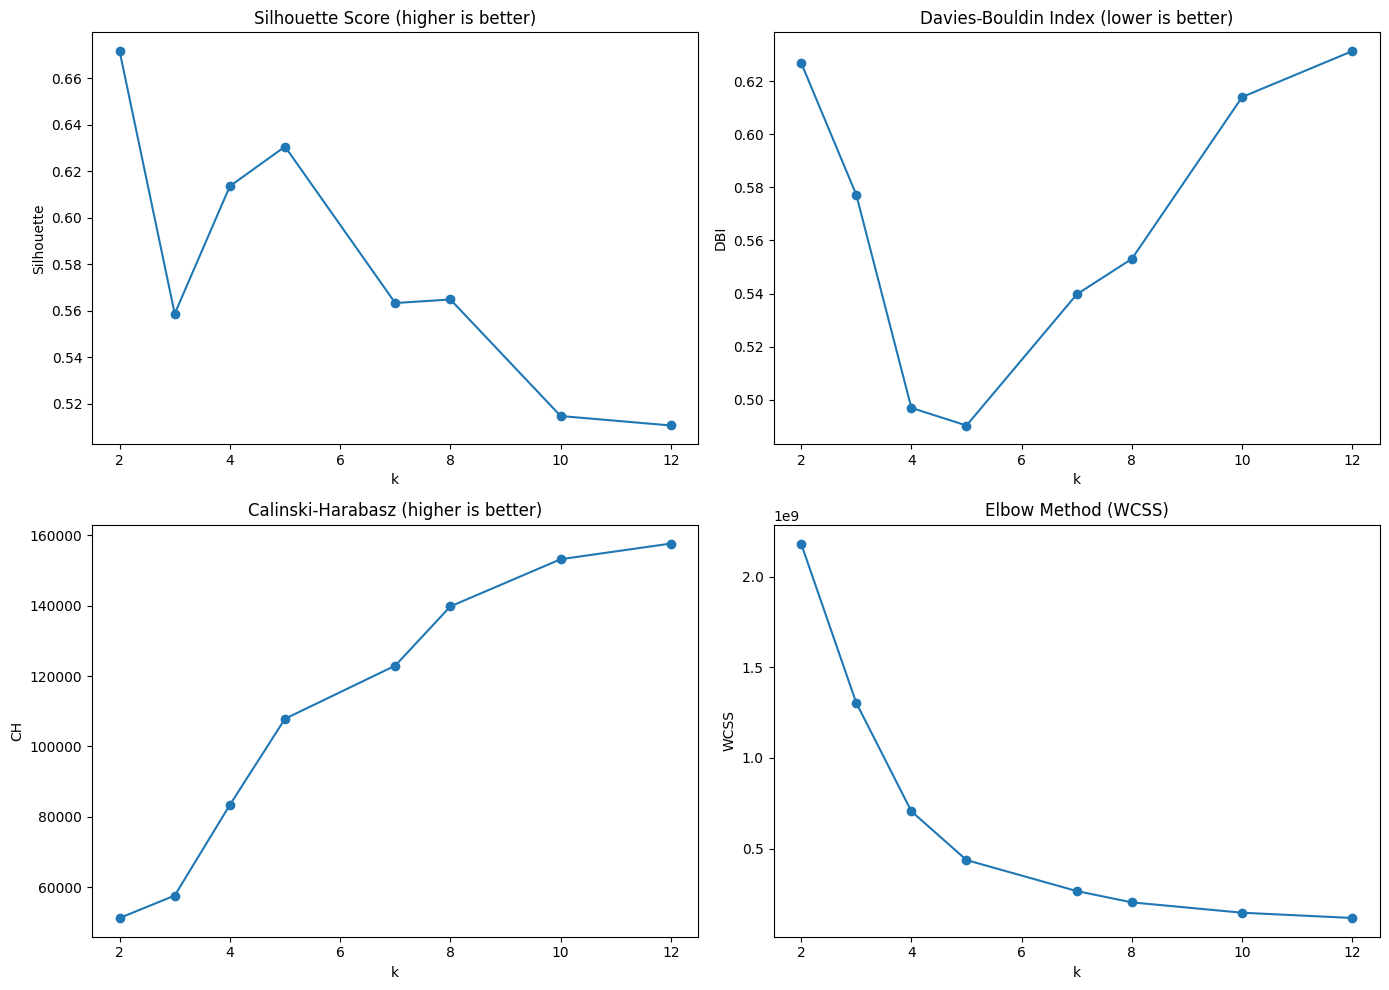

In [ ]:


# Load sampled data

df_sample = pd.read_csv("unsupervised_sampled_data.csv")

# Drop stratification variable for clustering (Vehicle Type)
X = df_sample.drop(columns=["Vehicle Type"]).values

# Evaluate different k
k_values = [2, 3, 4, 5, 7, 8, 10, 12]
results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    wcss = kmeans.inertia_

    results.append({"k": k, "Silhouette": sil, "Davies-Bouldin": db, "Calinski-Harabasz": ch, "WCSS": wcss})

# Convert to DataFrame
metrics_df = pd.DataFrame(results)
print(metrics_df)

# 3. Plot metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Silhouette
axes[0, 0].plot(metrics_df["k"], metrics_df["Silhouette"], marker='o')
axes[0, 0].set_title("Silhouette Score (higher is better)")
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("Silhouette")

# Davies-Bouldin
axes[0, 1].plot(metrics_df["k"], metrics_df["Davies-Bouldin"], marker='o')
axes[0, 1].set_title("Davies-Bouldin Index (lower is better)")
axes[0, 1].set_xlabel("k")
axes[0, 1].set_ylabel("DBI")

# Calinski-Harabasz
axes[1, 0].plot(metrics_df["k"], metrics_df["Calinski-Harabasz"], marker='o')
axes[1, 0].set_title("Calinski-Harabasz (higher is better)")
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("CH")

# Elbow (WCSS)
axes[1, 1].plot(metrics_df["k"], metrics_df["WCSS"], marker='o')
axes[1, 1].set_title("Elbow Method (WCSS)")
axes[1, 1].set_xlabel("k")
axes[1, 1].set_ylabel("WCSS")

plt.tight_layout()
plt.show()

In [ ]:
#running t-sne

# t-SNE parameters
print("Running t-SNE... this may take a few minutes....2mins!")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)
X_tsne = tsne.fit_transform(X)
print(" t-SNE completed.")

Running t-SNE... this may take a few minutes
✅ t-SNE completed.


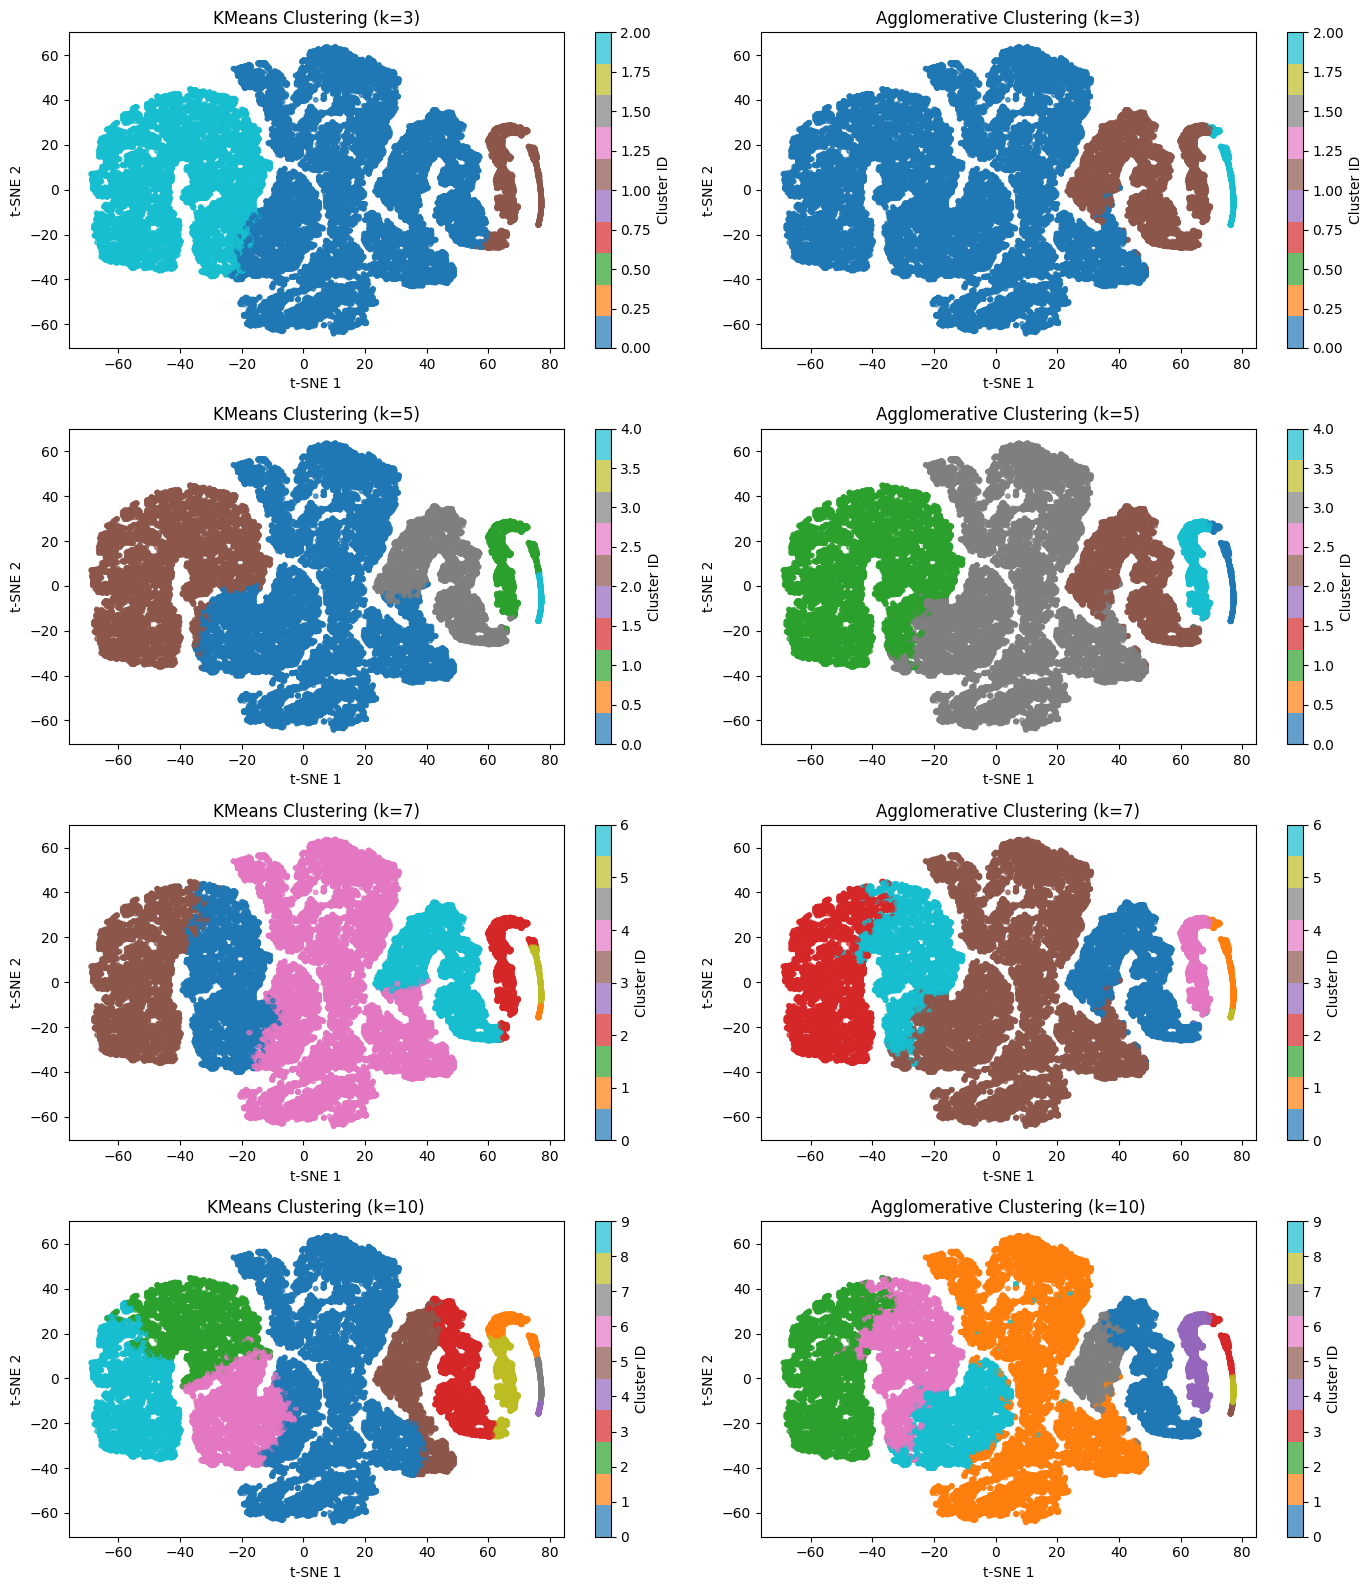

In [ ]:


# Define the list of k values
k_list = [3, 5, 7, 10]

# Prepare figure
fig, axes = plt.subplots(len(k_list), 2, figsize=(14, 4 * len(k_list)))
axes = axes.reshape(len(k_list), 2)

for i, k in enumerate(k_list):
    # --- KMeans ---
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X)

    sc1 = axes[i, 0].scatter(
        X_tsne[:, 0], X_tsne[:, 1],
        c=labels_kmeans, cmap='tab10', s=10, alpha=0.7
    )
    axes[i, 0].set_title(f"KMeans Clustering (k={k})")
    axes[i, 0].set_xlabel("t-SNE 1")
    axes[i, 0].set_ylabel("t-SNE 2")
    plt.colorbar(sc1, ax=axes[i, 0], label="Cluster ID")

    # --- Agglomerative ---
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_agg = agg.fit_predict(X)

    sc2 = axes[i, 1].scatter(
        X_tsne[:, 0], X_tsne[:, 1],
        c=labels_agg, cmap='tab10', s=10, alpha=0.7
    )
    axes[i, 1].set_title(f"Agglomerative Clustering (k={k})")
    axes[i, 1].set_xlabel("t-SNE 1")
    axes[i, 1].set_ylabel("t-SNE 2")
    plt.colorbar(sc2, ax=axes[i, 1], label="Cluster ID")

plt.tight_layout()
plt.show()

In [ ]:


# Prepare Data
# Keep Vehicle Type column for later analysis
vehicle_col = df_sample["Vehicle Type"]

# Remove it from X for fitting the model
X = df_sample.drop(columns=["Vehicle Type"]).values

# Fit clustering models
best_k = 5 

# --- KMeans ---
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

# --- Agglomerative ---
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(X)

# Create result DataFrame
df_with_clusters = df_sample.copy()
df_with_clusters["cluster_kmeans"] = kmeans_labels
df_with_clusters["cluster_agglomerative"] = agg_labels
df_with_clusters["Vehicle Type"] = vehicle_col 

# Save results
output_path = f"unsupervised_sampled_data_with_clusters_k{best_k}.csv"
df_with_clusters.to_csv(output_path, index=False)

print(f"Clustering output with k={best_k} saved to: {output_path}")
print(df_with_clusters.head())

✅ Clustering output with k=5 saved to: unsupervised_sampled_data_with_clusters_k5.csv
   hour  temperature_2m_pickup  relative_humidity_2m_pickup  \
0    18                   26.4                         93.0   
1    18                   26.4                         95.0   
2    20                   28.1                         88.0   
3    16                   14.6                         75.0   
4    20                   21.0                         94.0   

   dew_point_2m_pickup  precipitation_pickup  snowfall_pickup  \
0                 25.2                   0.0              0.0   
1                 25.6                   0.0              0.0   
2                 25.8                   0.0              0.0   
3                 10.2                   0.0              0.0   
4                 20.0                   0.0              0.0   

   wind_speed_10m_pickup  AvgVTAT_missing_flag  DriverRatings_missing_flag  \
0                    6.4                     0                    

In [30]:
df_with_clusters

,hour,temperature_2m_pickup,relative_humidity_2m_pickup,dew_point_2m_pickup,precipitation_pickup,snowfall_pickup,wind_speed_10m_pickup,AvgVTAT_missing_flag,DriverRatings_missing_flag,Avg VTAT_fill,...,Customer Rating_fill,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike,Vehicle Type,cluster_kmeans,cluster_agglomerative
0,18,26.4,93.0,25.2,0.0,0.0,6.4,0,0,6.3,...,5.000000,False,True,False,False,False,False,Go Mini,2,1
1,18,26.4,95.0,25.6,0.0,0.0,9.0,0,1,5.9,...,4.402546,False,False,False,False,False,False,Auto,0,3
2,20,28.1,88.0,25.8,0.0,0.0,3.7,0,1,5.6,...,4.408785,False,False,True,False,False,False,Go Sedan,0,3
3,16,14.6,75.0,10.2,0.0,0.0,1.6,0,0,5.9,...,4.300000,False,True,False,False,False,False,Go Mini,2,1
4,20,21.0,94.0,20.0,0.0,0.0,6.6,0,0,7.7,...,4.800000,False,True,False,False,False,False,Go Mini,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43790,11,35.6,17.0,7.0,0.0,0.0,16.3,0,1,5.6,...,4.402546,False,False,False,False,False,False,Auto,0,3
43791,18,25.2,77.0,20.8,0.0,0.0,3.3,0,0,11.5,...,4.200000,False,True,False,False,False,False,Go Mini,2,1
43792,5,31.5,50.0,19.9,0.0,0.0,1.8,0,0,9.2,...,4.700000,True,False,False,False,False,False,Bike,3,2
43793,22,26.4,83.0,23.2,0.0,0.0,10.1,0,0,9.7,...,3.900000,False,False,False,False,True,False,Uber XL,3,2


feature testing 

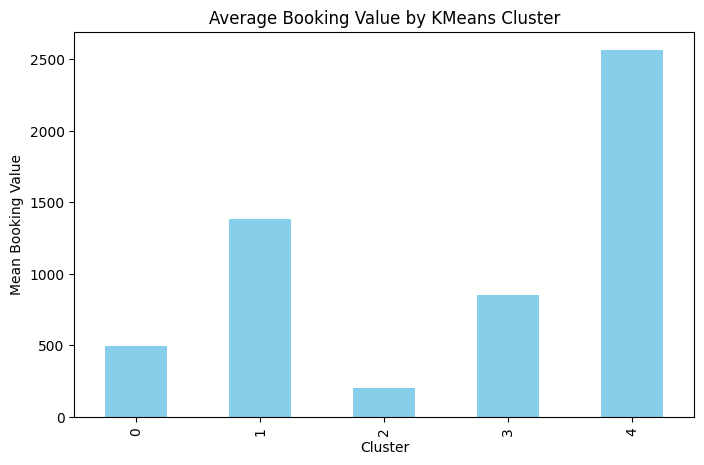

In [34]:

#result csv
df = pd.read_csv("unsupervised_sampled_data_with_clusters_k5.csv")

df.groupby("cluster_kmeans")["Booking Value_fill"].mean().plot(
    kind="bar", color="skyblue", figsize=(8,5)
)
plt.title("Average Booking Value by KMeans Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean Booking Value")
plt.show()

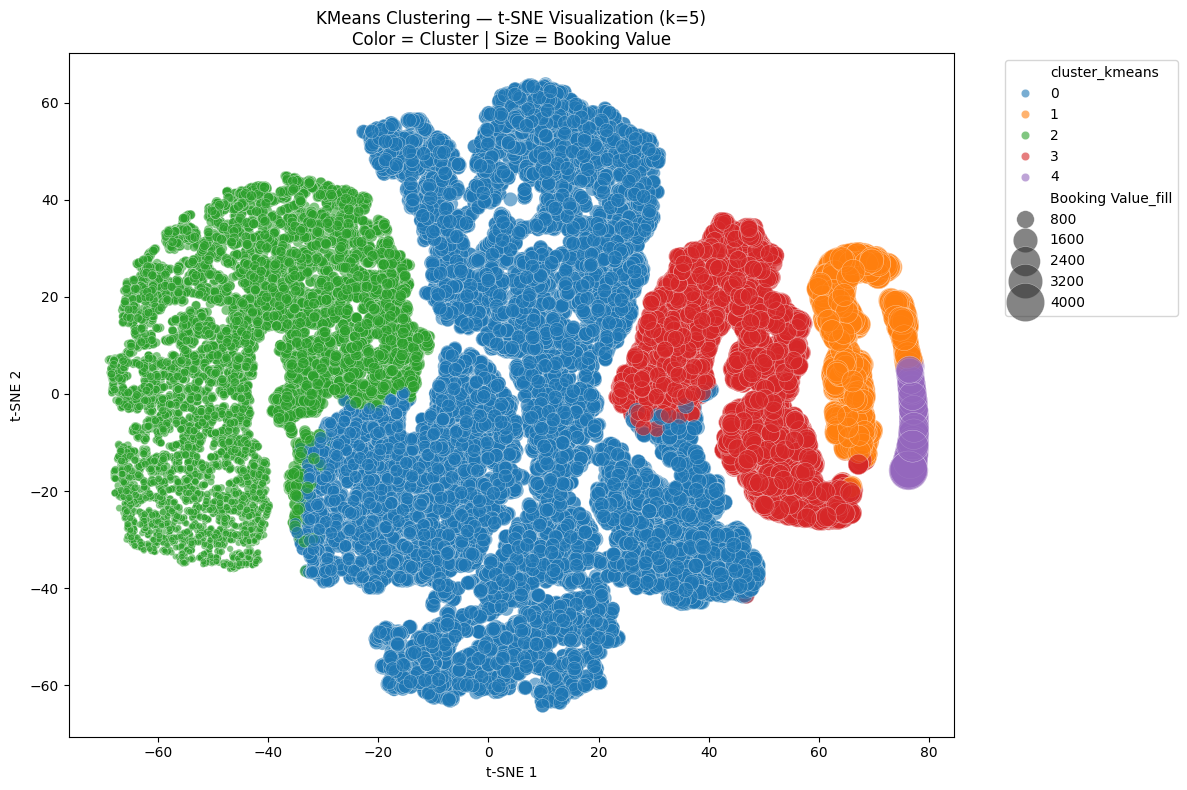

In [ ]:

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=df["cluster_kmeans"],      
    size=df["Booking Value_fill"],
    sizes=(20, 800),
    alpha=0.6,
    palette="tab10",
    edgecolor="white",
    linewidth=0.3
)
plt.title("KMeans Clustering — t-SNE Visualization (k=5)\nColor = Cluster | Size = Booking Value")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

In [ ]:


# Unique vehicle types + "All"
vehicle_types = df["Vehicle Type"].unique()
vehicle_options = ["All"] + list(vehicle_types)

# Define plotting function
def plot_by_vehicle(vehicle_type):
    plt.figure(figsize=(12, 8))

    # Filter dataset
    if vehicle_type != "All":
        mask = df["Vehicle Type"] == vehicle_type
        plot_data = df[mask]
        tsne_subset = X_tsne[mask]
    else:
        plot_data = df
        tsne_subset = X_tsne

    # Scatter plot
    sns.scatterplot(
        x=tsne_subset[:, 0],
        y=tsne_subset[:, 1],
        hue=plot_data["cluster_kmeans"],
        size=plot_data["Booking Value_fill"],
        sizes=(20, 800),
        alpha=0.6,
        palette="tab10",
        edgecolor="white",
        linewidth=0.3
    )

    plt.title(f"KMeans Clustering — t-SNE Visualization (k=5)\nVehicle Type: {vehicle_type}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
    plt.tight_layout()
    plt.show()

# Create interactive dropdown
interact(plot_by_vehicle, vehicle_type=vehicle_options)

interactive(children=(Dropdown(description='vehicle_type', options=('All', 'Go Mini', 'Auto', 'Go Sedan', 'Pre…

<function __main__.plot_by_vehicle(vehicle_type)>

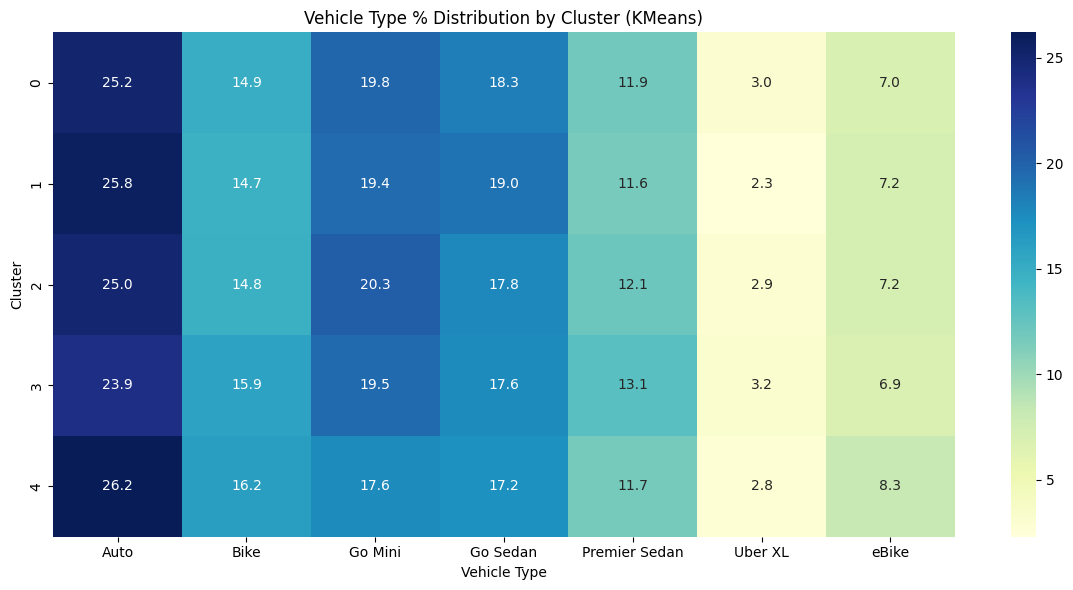

In [ ]:

# Convert to counts or percentages
cross_tab = pd.crosstab(df["cluster_kmeans"], df["Vehicle Type"], normalize='index') * 100

plt.figure(figsize=(12,6))
sns.heatmap(cross_tab, cmap="YlGnBu", annot=True, fmt=".1f")
plt.title("Vehicle Type % Distribution by Cluster (KMeans)")
plt.xlabel("Vehicle Type")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [ ]:

# Define time ranges
def hour_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

# Create a column for hour period if not already created
if "hour_period" not in df.columns:
    df["hour_period"] = df["hour"].apply(hour_period)

# Unique hour periods for dropdown
hour_options = ["All"] + list(df["hour_period"].unique())

#Define plotting function
def plot_by_hour(hour_filter):
    plt.figure(figsize=(12, 8))

    if hour_filter != "All":
        mask = df["hour_period"] == hour_filter
        plot_data = df[mask]
        tsne_subset = X_tsne[mask]
    else:
        plot_data = df
        tsne_subset = X_tsne

    sns.scatterplot(
        x=tsne_subset[:, 0],
        y=tsne_subset[:, 1],
        hue=plot_data["cluster_kmeans"],
        size=plot_data["Booking Value_fill"],
        sizes=(20, 800),
        alpha=0.6,
        palette="tab10",
        edgecolor="white",
        linewidth=0.3
    )

    plt.title(f"KMeans Clustering — t-SNE Visualization (k=5)\nHour Period: {hour_filter}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
    plt.tight_layout()
    plt.show()

# Create dropdown
interact(plot_by_hour, hour_filter=hour_options)

interactive(children=(Dropdown(description='hour_filter', options=('All', 'Evening', 'Afternoon', 'Morning', '…

<function __main__.plot_by_hour(hour_filter)>

In [44]:
# Group by cluster and hour, then compute average booking value
cluster_hour_avg = df.groupby(["cluster_kmeans", "hour"])["Booking Value_fill"].mean().reset_index()
cluster_hour_avg.rename(columns={"Booking Value_fill": "avg_booking_value"}, inplace=True)
print(cluster_hour_avg.head())

   cluster_kmeans  hour  avg_booking_value
0               0     0         499.054701
1               0     1         494.897709
2               0     2         493.603188
3               0     3         497.775232
4               0     4         492.276993


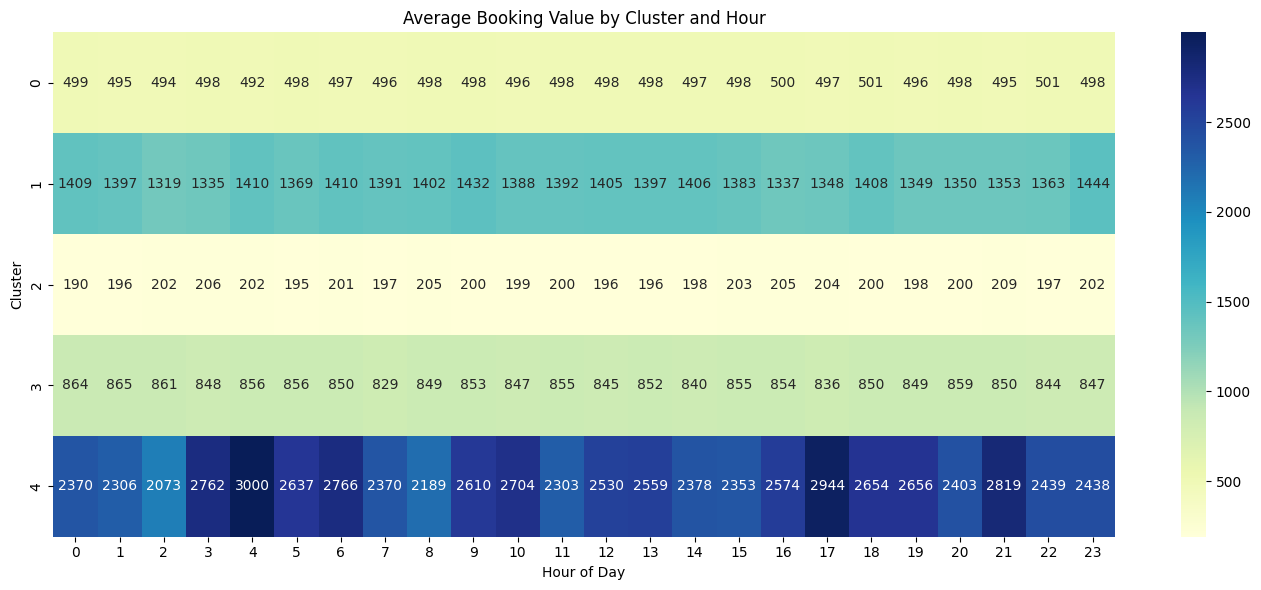

In [ ]:


# Pivot for heatmap
pivot_table = cluster_hour_avg.pivot(index="cluster_kmeans", columns="hour", values="avg_booking_value")

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Average Booking Value by Cluster and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

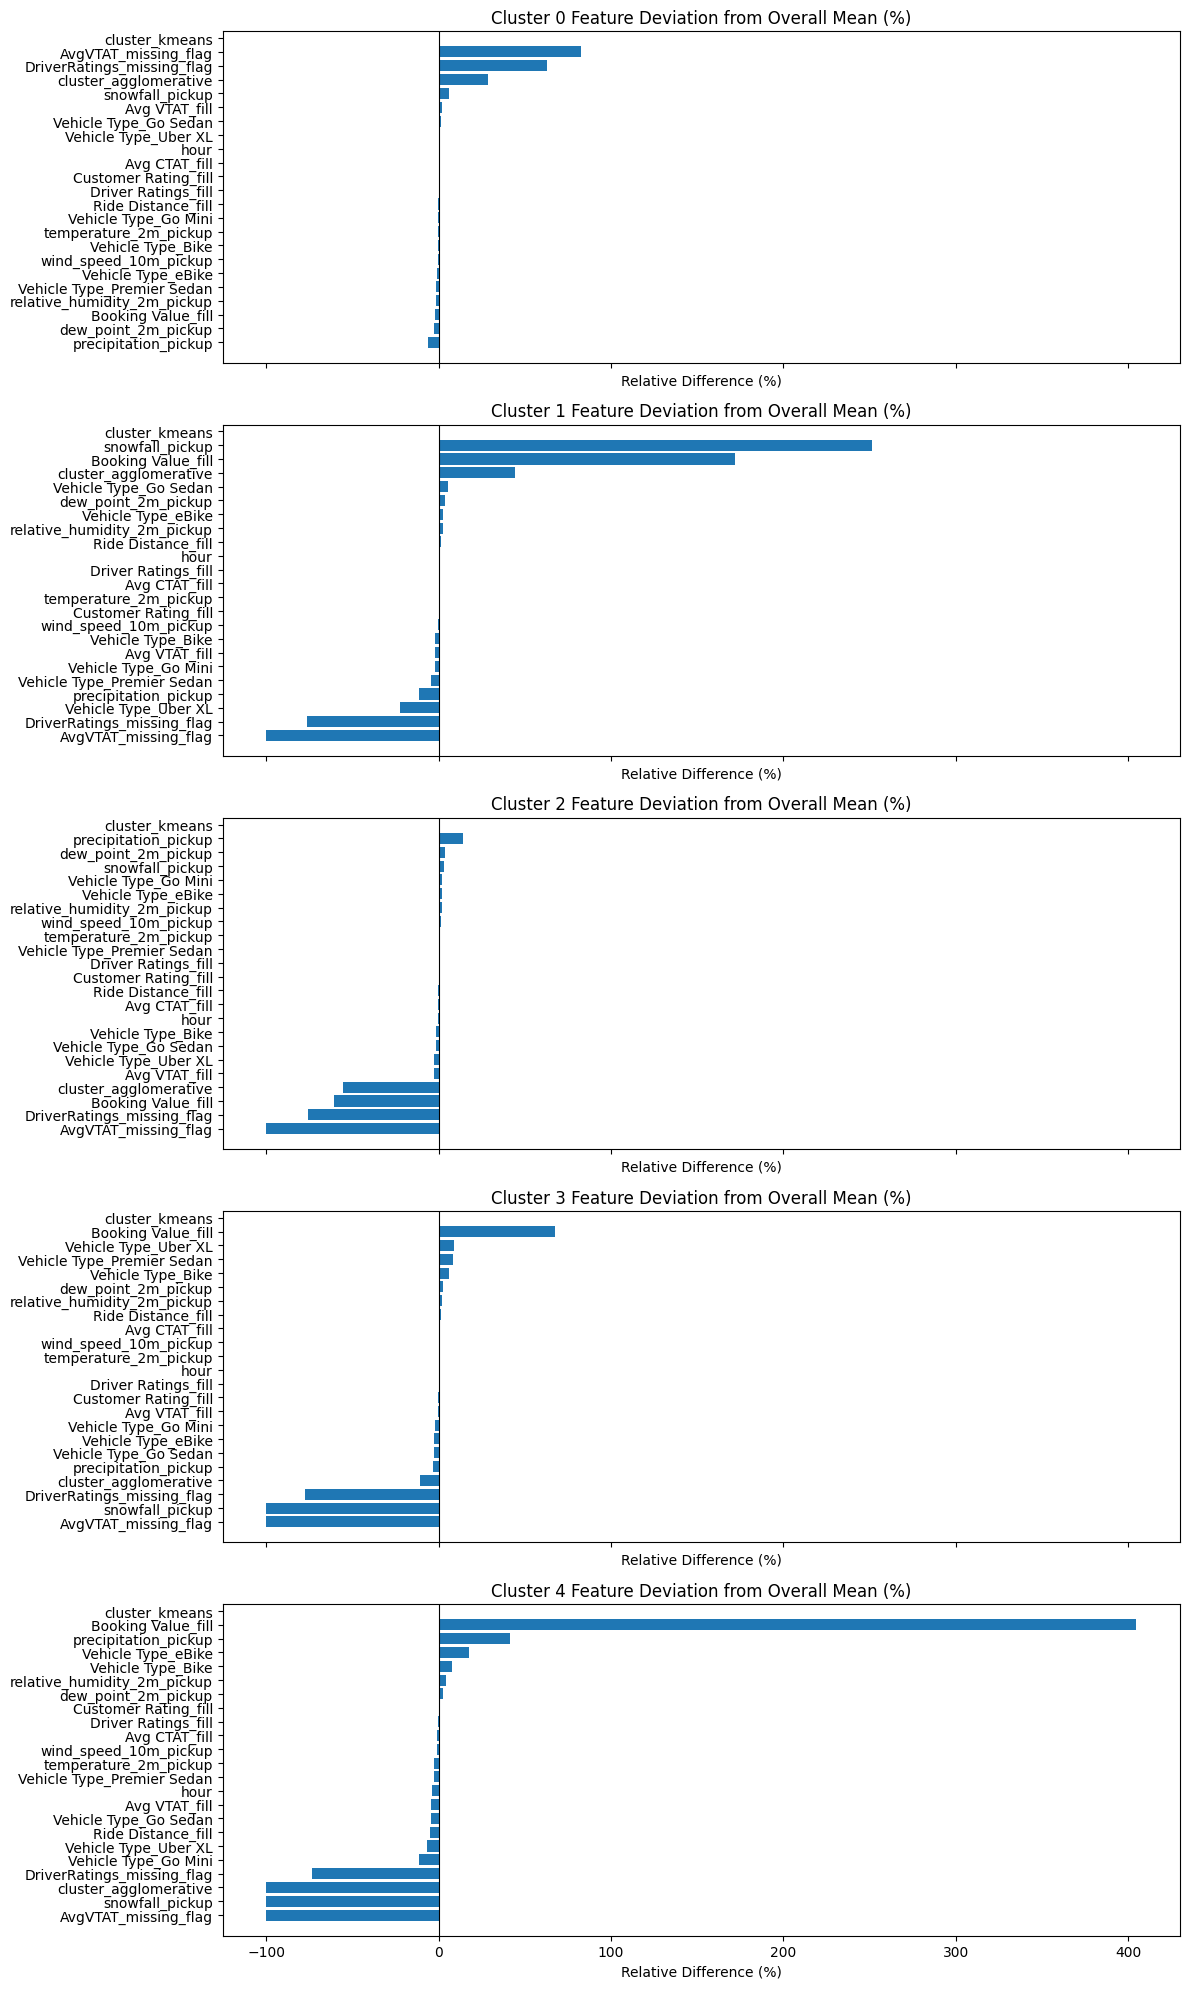

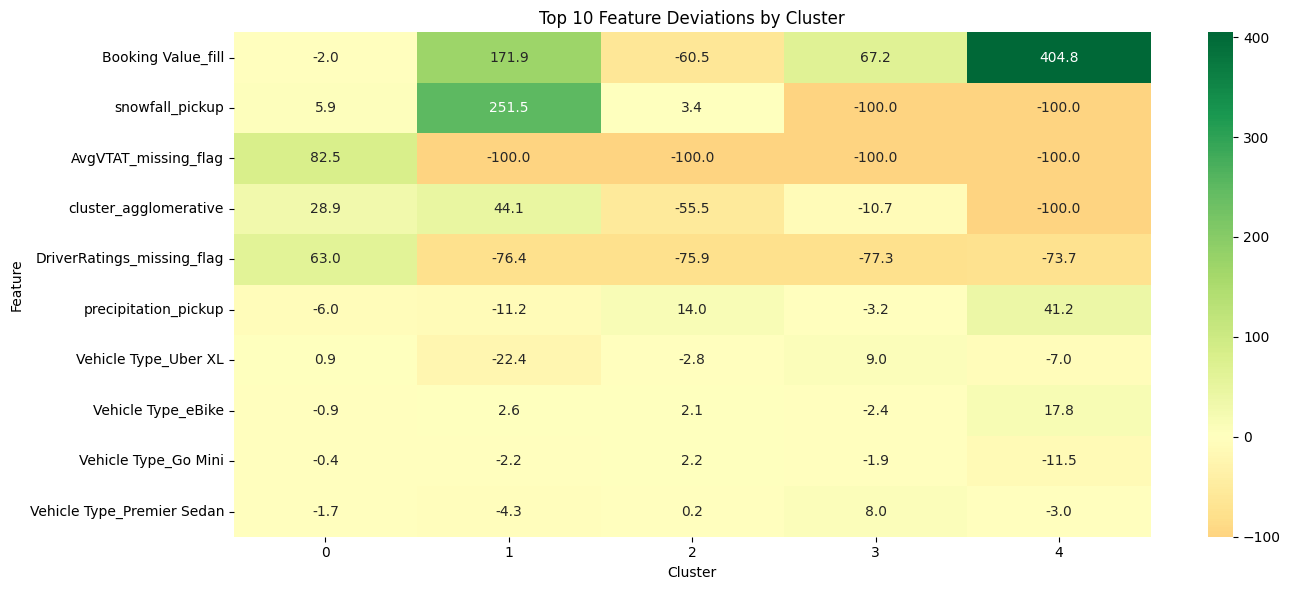

In [ ]:

# Compute overall mean of numeric columns
overall_mean = df.mean(numeric_only=True)

# Compute cluster means
cluster_means = df.groupby("cluster_kmeans").mean(numeric_only=True)

# Compute relative deviation for each cluster
relative_diff_all = ((cluster_means - overall_mean) / overall_mean) * 100
relative_diff_all = relative_diff_all.T  # transpose so features are rows

# Number of clusters
clusters = sorted(df["cluster_kmeans"].unique())

fig, axes = plt.subplots(len(clusters), 1, figsize=(12, 4 * len(clusters)), sharex=True)

for i, c in enumerate(clusters):
    rel_diff = relative_diff_all[c].sort_values()
    axes[i].barh(rel_diff.index, rel_diff.values)
    axes[i].set_title(f"Cluster {c} Feature Deviation from Overall Mean (%)")
    axes[i].set_xlabel("Relative Difference (%)")
    axes[i].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

N = 10
top_features = relative_diff_all.abs().max(axis=1).sort_values(ascending=False).head(N).index
relative_diff_top = relative_diff_all.loc[top_features]

# Heatmap view
plt.figure(figsize=(14, 6))
sns.heatmap(relative_diff_top, cmap="RdYlGn", center=0, annot=True, fmt=".1f")
plt.title(f"Top {N} Feature Deviations by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()